# SNN Training - DFUC2020
## Spiking Neural Network for Diabetic Foot Ulcer Detection

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

project_path = r"D:\DFUC_Project"
if project_path not in sys.path:
    sys.path.append(project_path)

from src.dataset import DFUCDataset, load_annotations
from src.models.snn_cnn import SNNCNNDetector
from src.losses import DetectionLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# Check if SNN model file is the old (bad) one
save_path = r"D:\DFUC_Project\saved_models\snn_cnn_baseline.pth"
if os.path.exists(save_path):
    sd = torch.load(save_path, map_location='cpu')
    has_cnn_keys = any(k.startswith('features.') for k in sd.keys())
    if has_cnn_keys:
        print("Old CNN weights detected in snn_cnn_baseline.pth - will overwrite with SNN weights")
    else:
        print(f"Existing SNN weights found: {list(sd.keys())[:3]}")

Old CNN weights detected in snn_cnn_baseline.pth - will overwrite with SNN weights


## 1. Load Data

In [3]:
train_image_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\images"
annotation_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\groundtruth.csv"

annotations = load_annotations(annotation_path)

dataset = DFUCDataset(train_image_path, annotations)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches: {len(dataloader)}")

Dataset size: 2000
Batches: 250


## 2. Initialize SNN Model

In [4]:
model = SNNCNNDetector(num_steps=10, beta=0.9).to(device)
criterion = DetectionLoss(box_loss_weight=5.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"SNN parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device: {next(model.parameters()).device}")

# Quick test forward pass
sample_img, sample_target = dataset[0]
with torch.no_grad():
    out = model(sample_img.unsqueeze(0).to(device))
print(f"Forward OK - output shape: {out.shape} (expected [1, 5])")

SNN parameters: 94,341
Model device: cuda:0
Forward OK - output shape: torch.Size([1, 5]) (expected [1, 5])


## 3. Training Loop

In [5]:
epochs = 50
train_losses = []
obj_losses = []
box_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_obj = 0.0
    running_box = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        total_loss, obj_loss, box_loss = criterion(predictions, targets)
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        running_obj += obj_loss.item()
        running_box += box_loss.item()

    epoch_loss = running_loss / len(dataloader)
    epoch_obj = running_obj / len(dataloader)
    epoch_box = running_box / len(dataloader)

    train_losses.append(epoch_loss)
    obj_losses.append(epoch_obj)
    box_losses.append(epoch_box)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{epochs}  Loss: {epoch_loss:.4f}  (Obj: {epoch_obj:.4f}, Box: {epoch_box:.4f})")

Epoch  1/50  Loss: 0.5247  (Obj: 0.0514, Box: 0.0947)
Epoch  5/50  Loss: 0.4661  (Obj: 0.0009, Box: 0.0930)
Epoch 10/50  Loss: 0.4621  (Obj: 0.0003, Box: 0.0923)
Epoch 15/50  Loss: 0.4618  (Obj: 0.0002, Box: 0.0923)
Epoch 20/50  Loss: 0.4573  (Obj: 0.0001, Box: 0.0914)
Epoch 25/50  Loss: 0.4519  (Obj: 0.0001, Box: 0.0904)
Epoch 30/50  Loss: 0.4532  (Obj: 0.0000, Box: 0.0906)
Epoch 35/50  Loss: 0.4479  (Obj: 0.0000, Box: 0.0896)
Epoch 40/50  Loss: 0.4455  (Obj: 0.0000, Box: 0.0891)
Epoch 45/50  Loss: 0.4435  (Obj: 0.0000, Box: 0.0887)
Epoch 50/50  Loss: 0.4433  (Obj: 0.0000, Box: 0.0887)


## 4. Training Loss Plot

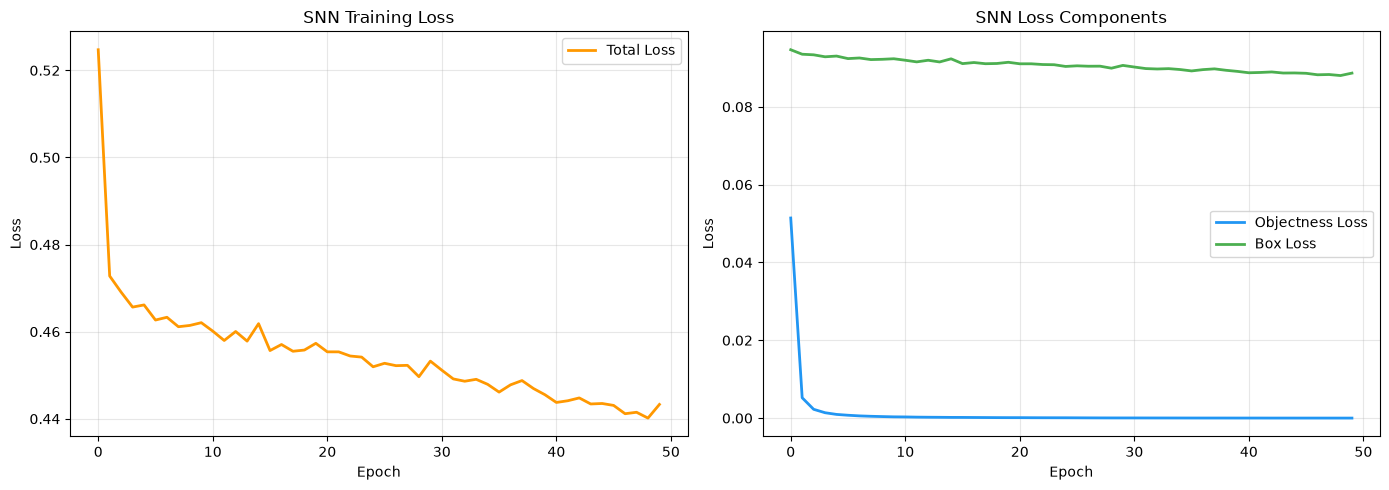

Final loss: 0.4433 (start: 0.5247)
Total epochs trained: 50


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Total Loss', color='#FF9800', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('SNN Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(obj_losses, label='Objectness Loss', color='#2196F3', linewidth=2)
axes[1].plot(box_losses, label='Box Loss', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('SNN Loss Components')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"D:\DFUC_Project\results\snn_training_loss.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Final loss: {train_losses[-1]:.4f} (start: {train_losses[0]:.4f})")
print(f"Total epochs trained: {len(train_losses)}")

## 5. Save Model

In [7]:
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model.state_dict(), save_path)

# Verify save
verify = torch.load(save_path, map_location='cpu')
is_snn = any(k.startswith('conv') or k.startswith('lif') for k in verify.keys())
print(f"Model saved to: {save_path}")
print(f"Verified: {'SNN weights' if is_snn else 'WARNING: wrong keys!'}")
print(f"Keys: {list(verify.keys())[:5]}...")

Model saved to: D:\DFUC_Project\saved_models\snn_cnn_baseline.pth
Verified: SNN weights
Keys: ['conv1.weight', 'conv1.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean']...
